In [1]:
pip install pyspark

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg, count, col, desc, sum

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Project 2 - Flights 1987") \
    .getOrCreate()

# Load the dataset
flights_df = spark.read.csv("../inputs/1987_flights.csv", header=True, inferSchema=True)

# Show row count of dataset
row_count = flights_df.count()
print(f"Row count of dataset: {row_count}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/19 20:55:13 WARN Utils: Your hostname, Codys-MacBook-Neo.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.9 instead (on interface en0)
26/06/19 20:55:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/19 20:55:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Row count of dataset: 1048575


In [3]:
# Show first part of dataset
flights_df.show(5)

+----+-----+----------+---------+-------+----------+-------+----------+-------------+---------+-------+-----------------+--------------+-------+--------+--------+------+----+--------+------+-------+---------+----------------+--------+------------+------------+--------+-------------+-----------------+
|Year|Month|DayofMonth|DayOfWeek|DepTime|CRSDepTime|ArrTime|CRSArrTime|UniqueCarrier|FlightNum|TailNum|ActualElapsedTime|CRSElapsedTime|AirTime|ArrDelay|DepDelay|Origin|Dest|Distance|TaxiIn|TaxiOut|Cancelled|CancellationCode|Diverted|CarrierDelay|WeatherDelay|NASDelay|SecurityDelay|LateAircraftDelay|
+----+-----+----------+---------+-------+----------+-------+----------+-------------+---------+-------+-----------------+--------------+-------+--------+--------+------+----+--------+------+-------+---------+----------------+--------+------------+------------+--------+-------------+-----------------+
|1987|   10|        14|        3|    741|       730|    912|       849|           PS|     1451

26/06/19 20:55:19 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [4]:
# Top 5 destination airports with longest departure delays in December

top5_delays = (
    flights_df
    .filter(flights_df.Month == 12)           # December only
    .filter(col("DepDelay") != "NA")  # Exclude rows with 'NA' in DepDelay
    .groupBy("Dest")                          # Group by destination airport
    .agg(avg("DepDelay").alias("AvgDepDelay"))
    .orderBy(desc("AvgDepDelay"))             # Largest delays first
    .limit(5)
)
top5_delays.show()


+----+------------------+
|Dest|       AvgDepDelay|
+----+------------------+
| ACV|              29.9|
| RDD|29.117117117117118|
| YKM| 27.74074074074074|
| HNL|25.615658362989326|
| BOI|25.210526315789473|
+----+------------------+



In [5]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
monthly_delays = (
    flights_df
    .filter(
        (col("DepDelay").isNotNull()) &
        (col("DepDelay") != "NA") &
        (col("DepDelay") != "")
    )
    .withColumn("DepDelay", col("DepDelay").cast("double"))
    .groupBy("Month")
    .agg(sum("DepDelay").alias("TotalDepDelay"))
    .orderBy("Month")
)
monthly_delays.show()

+-----+-------------+
|Month|TotalDepDelay|
+-----+-------------+
|   10|    2253727.0|
|   11|    2976603.0|
|   12|    2098492.0|
+-----+-------------+



In [7]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


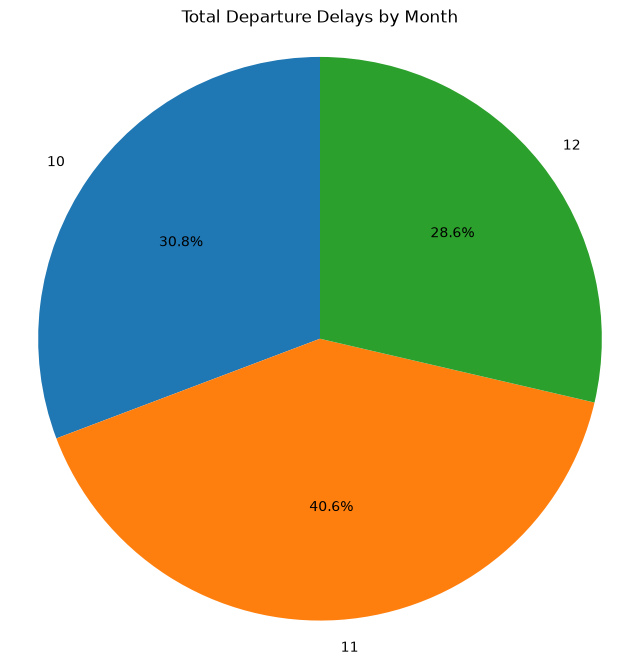

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.pyplot as plt

delays_df = monthly_delays.toPandas()

plt.figure(figsize=(8, 8))
plt.pie(
    delays_df["TotalDepDelay"],
    labels=delays_df["Month"].astype(str),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Total Departure Delays by Month")
plt.axis("equal")
plt.show()